# IT25103390 — KNN Classification (Final Evaluation: Implementation)
**Jayamini K.A.D.D. — Dataset:** UCI Mushroom (Chi-Square selected features, K=10)
**Course:** IT2011 — Artificial Intelligence and Machine Learning (SLIIT, Year 2, Semester 1)

**Problem:** binary classification — predict whether a mushroom is **edible (0)** or **poisonous (1)**.

## 1. Load preprocessed data & train/test split

In [6]:
import warnings
warnings.filterwarnings('ignore')
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, RocCurveDisplay)

RANDOM_STATE = 42
out_dir='results/eda_visualizations'
DATA_PATH = f'{out_dir}/outputs/step_M5_chi2_selected.csv'   # output of the Chi-Square notebook
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
print(df['class'].value_counts())
df.head()

Shape: (8124, 11)
class
0    4208
1    3916
Name: count, dtype: int64


,gill-color,ring-type,gill-size,stalk-root,bruises,gill-spacing,habitat,spore-print-color,population,stalk-surface-above-ring,class
0,4,4,1,2,1,0,5,2,3,2,1
1,4,4,0,1,1,0,1,3,2,2,0
2,5,4,0,1,1,0,3,3,2,2,0
3,5,4,1,2,1,0,5,2,3,2,1
4,4,0,0,2,0,1,1,3,0,2,0


In [7]:
X = df.drop(columns=['class'])
y = df['class']
feature_cols = X.columns.tolist()

# 80/20 stratified hold-out split: the test set is NEVER used during tuning
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
print('Train:', X_train.shape, ' Test:', X_test.shape)
print('Train class balance:', y_train.value_counts(normalize=True).round(3).to_dict())
print('Test  class balance:', y_test.value_counts(normalize=True).round(3).to_dict())

Train: (6499, 10)  Test: (1625, 10)
Train class balance: {0: 0.518, 1: 0.482}
Test  class balance: {0: 0.518, 1: 0.482}


**Hyperparameters tuned (`KNeighborsClassifier`):**
| Hyperparameter | Meaning | Values tried |
|---|---|---|
| `n_neighbors` | number of neighbours that vote (k) | 1, 3, 5, 7, 9, 11, 15, 21 |
| `weights` | `uniform` = equal votes, `distance` = closer neighbours count more | uniform, distance |
| `metric` | distance function | euclidean, manhattan (V1, V2) / hamming (V3) |

**Three model varieties** (all wrapped in a `Pipeline` so preprocessing is fitted *only on training folds* → no data leakage):
- **V1 – Label-encoded + StandardScaler** (baseline; treats category codes as numbers)
- **V2 – One-hot encoded** (each category becomes its own 0/1 column, so no false ordering)
- **V3 – Label-encoded + Hamming distance** (counts the fraction of features that differ — the natural metric for categorical data)

## Parameter tuning with GridSearchCV

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {'accuracy': 'accuracy', 'precision': 'precision', 'recall': 'recall',
           'f1': 'f1', 'roc_auc': 'roc_auc'}

def pick_best(cv_results):
    # Many settings tie at ~100%, so break ties explicitly: recall > f1 > accuracy,
    # then prefer the LARGER k (smoother, less sensitive to single noisy neighbours).
    r = pd.DataFrame(cv_results)
    r['k'] = r['param_knn__n_neighbors'].astype(int)
    r = r.sort_values(['mean_test_recall', 'mean_test_f1', 'mean_test_accuracy', 'k'],
                      ascending=[False, False, False, False])
    return int(r.index[0])

# ---------- V1: label-encoded + StandardScaler ----------
pipe_v1 = Pipeline([('scale', StandardScaler()), ('knn', KNeighborsClassifier())])
grid_v1 = {'knn__n_neighbors': [1, 3, 5, 7, 9, 11, 15, 21],
           'knn__weights': ['uniform', 'distance'],
           'knn__metric': ['euclidean', 'manhattan']}

# ---------- V2: one-hot encoded ----------
ohe = ColumnTransformer([('ohe', OneHotEncoder(handle_unknown='ignore'), feature_cols)])
pipe_v2 = Pipeline([('prep', ohe), ('knn', KNeighborsClassifier())])
grid_v2 = {'knn__n_neighbors': [1, 3, 5, 7, 9, 11, 15, 21],
           'knn__weights': ['uniform', 'distance'],
           'knn__metric': ['euclidean', 'manhattan']}

# ---------- V3: label-encoded + Hamming ----------
pipe_v3 = Pipeline([('knn', KNeighborsClassifier(algorithm='brute'))])
grid_v3 = {'knn__n_neighbors': [1, 3, 5, 7, 9, 11, 15, 21],
           'knn__weights': ['uniform', 'distance'],
           'knn__metric': ['hamming']}

searches = {}
for name, pipe, grid in [('V1 Label+Scaled', pipe_v1, grid_v1),
                         ('V2 One-Hot', pipe_v2, grid_v2),
                         ('V3 Hamming', pipe_v3, grid_v3)]:
    gs = GridSearchCV(pipe, grid, scoring=scoring, refit=pick_best, cv=cv,
                      n_jobs=-1, return_train_score=False)
    gs.fit(X_train, y_train)
    searches[name] = gs
    print(f'{name:16s} best params: {gs.best_params_}')
    print(f'{"":16s} CV recall={gs.cv_results_["mean_test_recall"][gs.best_index_]:.4f}  '
          f'CV f1={gs.cv_results_["mean_test_f1"][gs.best_index_]:.4f}  '
          f'CV acc={gs.cv_results_["mean_test_accuracy"][gs.best_index_]:.4f}')

V1 Label+Scaled  best params: {'knn__metric': 'euclidean', 'knn__n_neighbors': 21, 'knn__weights': 'distance'}
                 CV recall=1.0000  CV f1=1.0000  CV acc=1.0000
V2 One-Hot       best params: {'knn__metric': 'manhattan', 'knn__n_neighbors': 11, 'knn__weights': 'distance'}
                 CV recall=1.0000  CV f1=1.0000  CV acc=1.0000
V3 Hamming       best params: {'knn__metric': 'hamming', 'knn__n_neighbors': 11, 'knn__weights': 'distance'}
                 CV recall=1.0000  CV f1=1.0000  CV acc=1.0000


## Number of models trained

In [11]:
rows = []
for name, gs in searches.items():
    n_combos = len(gs.cv_results_['params'])
    rows.append({'Variety': name, 'Hyperparameter combinations': n_combos,
                 'CV folds': cv.get_n_splits(), 'Model fits (combos x folds)': n_combos * cv.get_n_splits()})
count_df = pd.DataFrame(rows)
count_df.loc[len(count_df)] = ['TOTAL', count_df.iloc[:, 1].sum(), '-', count_df.iloc[:, 3].sum()]
count_df

,Variety,Hyperparameter combinations,CV folds,Model fits (combos x folds)
0,V1 Label+Scaled,32,5,160
1,V2 One-Hot,32,5,160
2,V3 Hamming,16,5,80
3,TOTAL,80,-,400


### Effect of k (manual inspection of the tuning results)

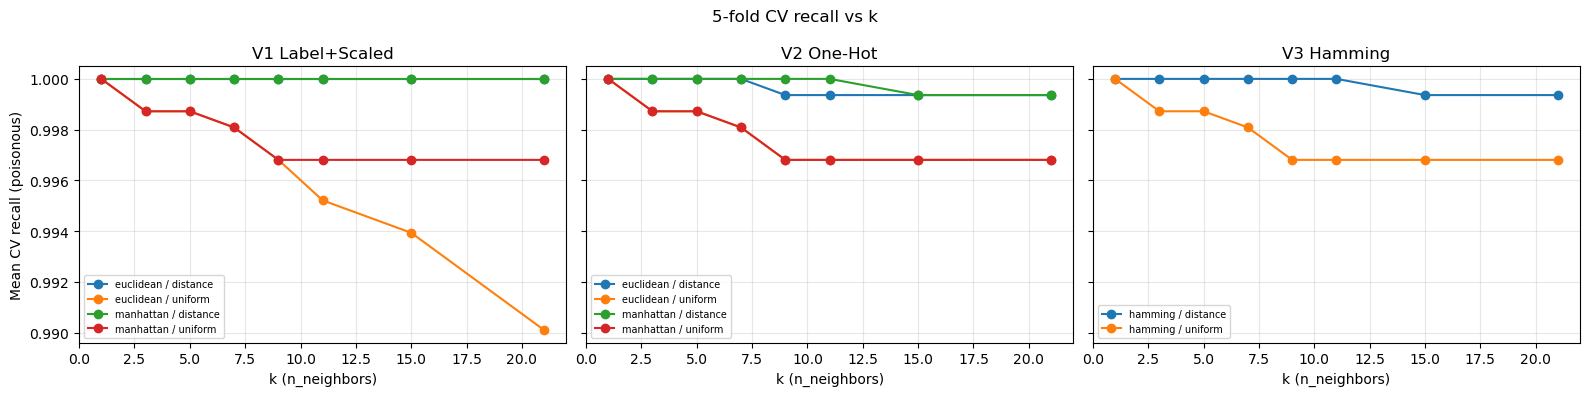

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, (name, gs) in zip(axes, searches.items()):
    r = pd.DataFrame(gs.cv_results_)
    r['k'] = r['param_knn__n_neighbors'].astype(int)
    r['label'] = r['param_knn__metric'].astype(str) + ' / ' + r['param_knn__weights'].astype(str)
    for lab, g in r.groupby('label'):
        g = g.sort_values('k')
        ax.plot(g['k'], g['mean_test_recall'], marker='o', label=lab)
    ax.set_title(name); ax.set_xlabel('k (n_neighbors)'); ax.grid(alpha=.3)
    ax.legend(fontsize=7)
axes[0].set_ylabel('Mean CV recall (poisonous)')
plt.suptitle('5-fold CV recall vs k')
plt.tight_layout()
os.makedirs(out_dir, exist_ok=True)
plt.savefig(f'{out_dir}/M5_knn_k_tuning.png', dpi=150)
plt.show()

## Evaluation on the held-out test set

In [13]:
results, preds = [], {}
for name, gs in searches.items():
    model = gs.best_estimator_
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    preds[name] = (y_pred, y_prob)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    results.append({'Variety': name,
                    'Best params': {k.replace('knn__', ''): v for k, v in gs.best_params_.items()},
                    'Accuracy': accuracy_score(y_test, y_pred),
                    'Precision': precision_score(y_test, y_pred),
                    'Recall': recall_score(y_test, y_pred),
                    'F1': f1_score(y_test, y_pred),
                    'ROC-AUC': roc_auc_score(y_test, y_prob),
                    'False negatives (poisonous called edible)': fn,
                    'False positives': fp})
results_df = pd.DataFrame(results)
pd.set_option('display.max_colwidth', 80)
results_df.round(4)

,Variety,Best params,Accuracy,Precision,Recall,F1,ROC-AUC,False negatives (poisonous called edible),False positives
0,V1 Label+Scaled,"{'metric': 'euclidean', 'n_neighbors': 21, 'weights': 'distance'}",1.0,1.0,1.0,1.0,1.0,0,0
1,V2 One-Hot,"{'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}",1.0,1.0,1.0,1.0,1.0,0,0
2,V3 Hamming,"{'metric': 'hamming', 'n_neighbors': 11, 'weights': 'distance'}",1.0,1.0,1.0,1.0,1.0,0,0


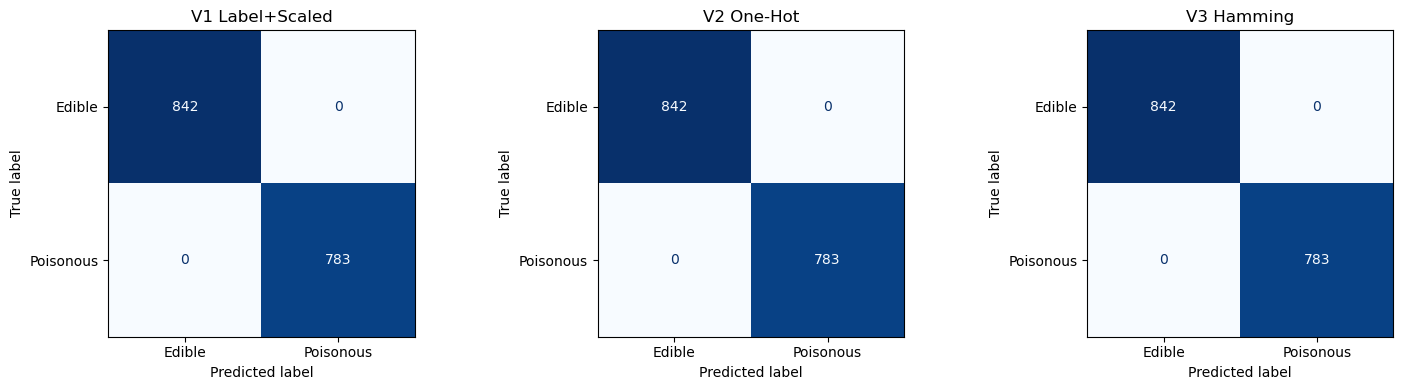

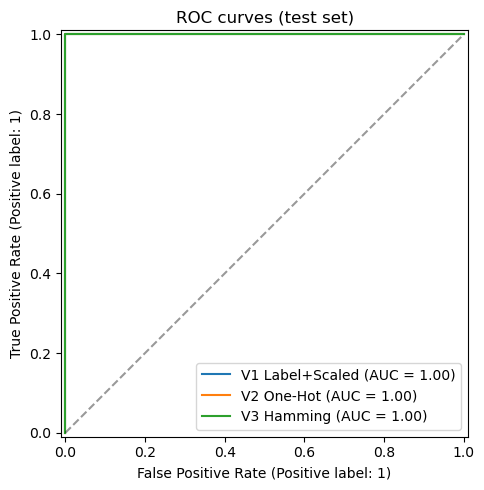

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, (y_pred, _)) in zip(axes, preds.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                           display_labels=['Edible', 'Poisonous']).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.savefig(f'{out_dir}/M5_knn_confusion_matrices.png', dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
for name, (_, y_prob) in preds.items():
    RocCurveDisplay.from_predictions(y_test, y_prob, name=name, ax=ax)
ax.plot([0, 1], [0, 1], 'k--', alpha=.4)
ax.set_title('ROC curves (test set)')
plt.tight_layout()
plt.savefig(f'{out_dir}/M5_knn_roc.png', dpi=150)
plt.show()

In [15]:
best_name = results_df.sort_values(['Recall', 'F1', 'Accuracy'], ascending=False).iloc[0]['Variety']
print('Best variety on test set:', best_name)
print(classification_report(y_test, preds[best_name][0], target_names=['Edible', 'Poisonous'], digits=4))

Best variety on test set: V1 Label+Scaled
              precision    recall  f1-score   support

      Edible     1.0000    1.0000    1.0000       842
   Poisonous     1.0000    1.0000    1.0000       783

    accuracy                         1.0000      1625
   macro avg     1.0000    1.0000    1.0000      1625
weighted avg     1.0000    1.0000    1.0000      1625



### Check for overfitting: train vs CV vs test (best variety)

In [16]:
gs = searches[best_name]
b = gs.best_index_
print(f"Train accuracy : {accuracy_score(y_train, gs.best_estimator_.predict(X_train)):.4f}")
print(f"CV accuracy    : {gs.cv_results_['mean_test_accuracy'][b]:.4f} (+/- {gs.cv_results_['std_test_accuracy'][b]:.4f})")
print(f"Test accuracy  : {accuracy_score(y_test, gs.best_estimator_.predict(X_test)):.4f}")

Train accuracy : 1.0000
CV accuracy    : 1.0000 (+/- 0.0000)
Test accuracy  : 1.0000


## Comparison & conclusion

In [17]:
cmp_cols = ['Variety', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC',
            'False negatives (poisonous called edible)', 'False positives']
results_df[cmp_cols].round(4)

,Variety,Accuracy,Precision,Recall,F1,ROC-AUC,False negatives (poisonous called edible),False positives
0,V1 Label+Scaled,1.0,1.0,1.0,1.0,1.0,0,0
1,V2 One-Hot,1.0,1.0,1.0,1.0,1.0,0,0
2,V3 Hamming,1.0,1.0,1.0,1.0,1.0,0,0


In [18]:
os.makedirs('results/outputs', exist_ok=True)
results_df.drop(columns=['Best params']).round(4).to_csv('results/outputs/M5_knn_results.csv', index=False)
print('Saved: results/outputs/M5_knn_results.csv')

Saved: results/outputs/M5_knn_results.csv
